# SDV Models: Comprehensive Evaluation — Adult Census Income

This notebook evaluates four synthetic data generation models on the **Adult Census Income** dataset (`Datasets/adult_census.csv`):
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using fidelity, utility, and privacy metrics (KS / column shapes, JS divergence, Wasserstein, Gower, MMD, cosine similarity, Hungarian matching, Mahalanobis, MIA, and TRTR/TSTR utility).

**Template**: adapted from `1. Cancer.ipynb` for the Adult Census dataset.

**Target variable**: `income` (binary encoded: `0 = <=50K`, `1 = >50K`)

**Speed / GPU (patten A100s)**: the training cell picks an idle A100 (`CUDA_VISIBLE_DEVICES`), caps CPU threads (avoids thrashing under high load), and trains all SDV models on a **1000-row** subsample (40 epochs / batch 500 in `FAST_MODE`). **Restart the kernel** before the training cell so GPU isolation applies. Set `FAST_MODE=False` for a full 48k × 300-epoch run.


## Data Loading and Setup


In [1]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Load Adult Census Income dataset
candidates = [
    Path.cwd() / "Datasets" / "adult_census.csv",
    Path.cwd().parent / "Datasets" / "adult_census.csv",
    Path(r"/home/gopi.battineni/SYNTH_BENCHMARK/Datasets/adult_census.csv"),
]
data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "adult_census.csv not found. Expected under Datasets/ relative to the project root."
    )

adult_data = pd.read_csv(data_path)

# Normalize alternate column names used by some Adult dumps
adult_data = adult_data.rename(
    columns={
        "gender": "sex",
        "educational-num": "education-num",
    }
)

# Strip whitespace from object columns, then treat '?' as missing
for col in adult_data.select_dtypes(include=["object"]).columns:
    adult_data[col] = adult_data[col].astype(str).str.strip()
adult_data = adult_data.replace("?", np.nan)

if "income" not in adult_data.columns:
    raise KeyError("Column 'income' not found in Adult Census dataset")

# Normalize income labels, then encode as binary 0/1 (same pattern as Cancer target)
adult_data["income"] = (
    adult_data["income"]
    .astype(str)
    .str.replace(r"\.$", "", regex=True)
    .replace({">50K": ">=50K", "<=50K": "<=50K"})
)
adult_data = adult_data.dropna(subset=["income"]).reset_index(drop=True)
adult_data["income"] = adult_data["income"].map({"<=50K": 0, ">=50K": 1, ">50K": 1})
if adult_data["income"].isna().any():
    raise ValueError("Unmapped income labels remain after encoding")

# Drop remaining missing values for stable SDV fitting
_before = len(adult_data)
adult_data = adult_data.dropna().reset_index(drop=True)
print(f"Dropped {_before - len(adult_data)} rows with missing feature values")

# Alias used by some downstream cells
data = adult_data

# SDV metadata
import sdv
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(adult_data)
# Keep binary income as categorical for synthesizers that benefit from discrete targets
metadata.update_column(column_name="income", sdtype="categorical")

print(f"Loaded from: {data_path}")
print(f"Data shape: {adult_data.shape}")
print(f"Columns: {list(adult_data.columns)}")
print("\nIncome distribution (0 = <=50K, 1 = >50K):")
print(adult_data["income"].value_counts(dropna=False))
print("\nMissing values (top):")
miss = adult_data.isnull().sum()
print(miss[miss > 0].sort_values(ascending=False).head(20) if miss.any() else "None")


Dropped 2399 rows with missing feature values
Loaded from: /home/gopi.battineni/SYNTH_BENCHMARK/Datasets/adult_census.csv
Data shape: (46443, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Income distribution (0 = <=50K, 1 = >50K):
income
0    35089
1    11354
Name: count, dtype: int64

Missing values (top):
None


# Generating synthetic data

In [2]:
# --- GPU selection MUST happen before importing torch ---
# If this cell was run before, Restart Kernel first or CUDA_VISIBLE_DEVICES is ignored.
import os
import subprocess
import sys
import time

# Cap CPU threads BEFORE torch/numpy work. Patten is often heavily loaded
# (load average >> cores); unbounded OpenMP/torch threads thrash and starve the GPU.
_CPU_THREADS = "8"
for _k in (
    "OMP_NUM_THREADS",
    "MKL_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
):
    os.environ[_k] = _CPU_THREADS


def _nvidia_gpu_stats():
    """Return list of dicts: index, free_mib, util_pct, other_pids."""
    out = subprocess.check_output(
        [
            "nvidia-smi",
            "--query-gpu=index,memory.free,utilization.gpu",
            "--format=csv,nounits,noheader",
        ],
        text=True,
    )
    rows = []
    for line in out.strip().splitlines():
        idx_s, free_s, util_s = [x.strip() for x in line.split(",")]
        rows.append(
            {
                "index": int(idx_s),
                "free_mib": int(free_s),
                "util_pct": int(util_s),
                "other_pids": [],
            }
        )

    # Prefer GPUs with no foreign compute processes (avoids sharing a busy A100).
    try:
        apps = subprocess.check_output(
            [
                "nvidia-smi",
                "--query-compute-apps=gpu_uuid,pid,used_gpu_memory",
                "--format=csv,nounits,noheader",
            ],
            text=True,
        ).strip()
        uuid_map = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=index,uuid", "--format=csv,nounits,noheader"],
            text=True,
        )
        uuid_to_idx = {}
        for line in uuid_map.strip().splitlines():
            idx_s, uuid = [x.strip() for x in line.split(",")]
            uuid_to_idx[uuid] = int(idx_s)
        by_idx = {r["index"]: r for r in rows}
        me = os.getpid()
        if apps:
            for line in apps.splitlines():
                uuid, pid_s, _mem = [x.strip() for x in line.split(",")]
                pid = int(pid_s)
                if pid == me:
                    continue
                idx = uuid_to_idx.get(uuid)
                if idx is not None:
                    by_idx[idx]["other_pids"].append(pid)
    except Exception as exc:
        print(f"(compute-app scan skipped: {exc})")
    return rows


def _select_patten_gpu(min_free_mib=8000, max_util_pct=10):
    """
    Prefer an idle A100 on patten: no other compute PIDs, low util, then free mem.
    Isolates it via CUDA_VISIBLE_DEVICES so SDV's device='cuda' hits that GPU only.
    """
    stats = _nvidia_gpu_stats()
    print("GPU inventory (nvidia-smi):")
    for r in stats:
        n_others = len(r["other_pids"])
        print(
            f"  GPU {r['index']}: free={r['free_mib']} MiB | "
            f"util={r['util_pct']}% | other_compute_pids={n_others}"
        )

    idle = [
        r
        for r in stats
        if r["free_mib"] >= min_free_mib
        and r["util_pct"] <= max_util_pct
        and len(r["other_pids"]) == 0
    ]
    if not idle:
        idle = [
            r
            for r in stats
            if r["free_mib"] >= min_free_mib and r["util_pct"] <= max_util_pct
        ]
    pool = idle if idle else stats
    pool = sorted(
        pool,
        key=lambda r: (len(r["other_pids"]), r["util_pct"], -r["free_mib"]),
    )
    best_idx = pool[0]["index"]
    os.environ["CUDA_VISIBLE_DEVICES"] = str(best_idx)
    os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
    print(
        f"Selected physical GPU {best_idx} "
        f"(CUDA_VISIBLE_DEVICES={best_idx}; SDV will see it as cuda:0)"
    )
    return best_idx


_TORCH_ALREADY_LOADED = "torch" in sys.modules
if _TORCH_ALREADY_LOADED:
    print(
        "Note: torch is already loaded in this kernel — CUDA_VISIBLE_DEVICES "
        "isolation may not apply. Prefer Kernel → Restart for a clean GPU pin."
    )
    PHYSICAL_GPU = _select_patten_gpu()  # still records preferred index / env
else:
    PHYSICAL_GPU = _select_patten_gpu()

# Import SDV/torch AFTER CUDA_VISIBLE_DEVICES is set (on a fresh kernel)
from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer,
)
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic
import torch

assert torch.cuda.is_available(), "CUDA not available — check drivers / conda env gopi"
torch.set_num_threads(int(_CPU_THREADS))
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass  # interop threads can only be set once per process

# Map preferred physical GPU → visible torch index
_visible = torch.cuda.device_count()
if not _TORCH_ALREADY_LOADED and os.environ.get("CUDA_VISIBLE_DEVICES") == str(PHYSICAL_GPU):
    _local_idx = 0  # isolated: only one device visible
elif _visible == 1:
    _local_idx = 0
else:
    # Both A100s visible — pick the idle one among cuda:0/cuda:1
    _stats = {r["index"]: r for r in _nvidia_gpu_stats()}
    _cands = []
    for local in range(_visible):
        # When all GPUs are visible, local index == physical index on patten
        st = _stats.get(local, {"other_pids": [0], "util_pct": 100, "free_mib": 0})
        _cands.append((len(st["other_pids"]), st["util_pct"], -st["free_mib"], local))
    _cands.sort()
    _local_idx = _cands[0][3]
    PHYSICAL_GPU = _local_idx

torch.cuda.set_device(_local_idx)
torch.backends.cudnn.benchmark = True
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass
_probe = torch.randn(2048, 2048, device=f"cuda:{_local_idx}")
_ = _probe @ _probe.T
torch.cuda.synchronize()
print(
    f"Torch sees {_visible} device(s); using cuda:{_local_idx} "
    f"({torch.cuda.get_device_name(_local_idx)}); "
    f"cpu_threads={torch.get_num_threads()}; "
    f"allocated={torch.cuda.memory_allocated()/1024**2:.0f} MiB"
)
del _probe
torch.cuda.empty_cache()

# Synthetic sample size for quality reports (privacy cells can use more later)
n_samples = 1000

# Speed knobs for patten A100s
# FAST_MODE=True  → fewer epochs on a 1000-row train subsample (fast)
# FAST_MODE=False → 300 epochs still on 1000 rows (quality-oriented, still quick vs full Adult)
FAST_MODE = True
EPOCHS = 40 if FAST_MODE else 300
# CTGAN requires batch_size % pac == 0 (pac=10) and batch_size <= n_rows.
BATCH_SIZE = 500
TRAIN_ROWS = 1000  # train all SDV models on 1000 samples (not full Adult)

train_df = adult_data.sample(n=min(TRAIN_ROWS, len(adult_data)), random_state=42).reset_index(drop=True)
print(f"Training subsample: {len(train_df)} / {len(adult_data)} rows (quality eval still uses full Adult)")

gpu_kwargs = {
    "enable_gpu": True,
    "verbose": True,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
}
print(
    f"Neural synthesizer settings: epochs={EPOCHS}, batch_size={BATCH_SIZE}, "
    f"physical_gpu={PHYSICAL_GPU}, enable_gpu=True, OMP/torch threads={_CPU_THREADS}, train_rows={len(train_df)}"
)

models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata, **gpu_kwargs),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata, **gpu_kwargs),
    "TVAE": TVAESynthesizer(metadata=metadata, **gpu_kwargs),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata),
}

# Keep named aliases so later cells do not re-fit from scratch
ctgan = models["CTGAN"]
copulagan = models["CopulaGAN"]
tvae = models["TVAE"]
gaussiancopula = models["GaussianCopula"]

synthetic_datasets = {}
diagnostic_reports = {}
quality_reports = {}
summary = []

NEURAL = {"CTGAN", "CopulaGAN", "TVAE"}

for name, model in models.items():
    fit_df = train_df  # all models (including GaussianCopula) train on the 1000-row subsample
    t0 = time.perf_counter()
    print(f"\nTraining {name} on {len(fit_df)} rows (GPU {PHYSICAL_GPU})...")
    model.fit(fit_df)
    elapsed = time.perf_counter() - t0
    print(f"  fit wall-time: {elapsed/60:.1f} min")

    # Confirm the neural model stayed on CUDA
    if name in NEURAL:
        inner = getattr(model, "_model", None)
        device = getattr(inner, "_device", None) if inner is not None else None
        print(f"  model device: {device}")
        print(f"  GPU mem allocated={torch.cuda.memory_allocated()/1024**2:.0f} MiB")
        assert device is not None and "cuda" in str(device), (
            f"{name} is not on CUDA ({device}). Restart kernel and re-run."
        )

    synthetic_data = model.sample(n_samples)
    synthetic_datasets[name] = synthetic_data

    diagnostic_report = run_diagnostic(
        real_data=adult_data,
        synthetic_data=synthetic_data,
        metadata=metadata,
    )
    quality_report = evaluate_quality(
        real_data=adult_data,
        synthetic_data=synthetic_data,
        metadata=metadata,
    )

    diagnostic_reports[name] = diagnostic_report
    quality_reports[name] = quality_report
    summary.append((name, diagnostic_report.get_score(), quality_report.get_score()))
    torch.cuda.empty_cache()

summary_df = pd.DataFrame(summary, columns=["Model", "Diagnostic Score", "Quality Score"])
summary_df = summary_df.sort_values("Quality Score", ascending=False).reset_index(drop=True)

print("\nModel comparison (Adult Census):")
display(summary_df)

best_model_name = summary_df.loc[0, "Model"]
best_synthetic_data = synthetic_datasets[best_model_name]
print(f"\nBest model by quality score: {best_model_name}")
display(best_synthetic_data.head())


Note: torch is already loaded in this kernel — CUDA_VISIBLE_DEVICES isolation may not apply. Prefer Kernel → Restart for a clean GPU pin.
GPU inventory (nvidia-smi):
  GPU 0: free=77048 MiB | util=0% | other_compute_pids=2
  GPU 1: free=77140 MiB | util=0% | other_compute_pids=1
Selected physical GPU 1 (CUDA_VISIBLE_DEVICES=1; SDV will see it as cuda:0)
Torch sees 1 device(s); using cuda:0 (NVIDIA A100 80GB PCIe); cpu_threads=8; allocated=40 MiB
Training subsample: 1000 / 46443 rows (quality eval still uses full Adult)
Neural synthesizer settings: epochs=40, batch_size=500, physical_gpu=1, enable_gpu=True, OMP/torch threads=8, train_rows=1000

Training CTGAN on 1000 rows (GPU 1)...


Gen. (+01.25) | Discrim. (+00.05): 100%|██████████| 40/40 [00:07<00:00,  5.44it/s]


  fit wall-time: 0.3 min
  model device: cuda
  GPU mem allocated=35 MiB
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 15/15 [00:00<00:00, 146.34it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 140.33it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 86.26it/s]|
Column Shapes Score: 86.74%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:02<00:00, 51.49it/s]|
Column Pair Trends Score: 72.05%

Overall Score (Average): 79.4%


Training CopulaGAN on 1000 rows (GPU 1)...


Gen. (+01.16) | Discrim. (+00.21): 100%|██████████| 40/40 [00:06<00:00,  5.86it/s]


  fit wall-time: 0.2 min
  model device: cuda
  GPU mem allocated=37 MiB
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 15/15 [00:00<00:00, 140.06it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 194.13it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 83.59it/s]|
Column Shapes Score: 80.38%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:01<00:00, 75.54it/s]|
Column Pair Trends Score: 69.45%

Overall Score (Average): 74.91%


Training TVAE on 1000 rows (GPU 1)...


Loss: +18.07: 100%|██████████| 40/40 [00:01<00:00, 23.52it/s]


  fit wall-time: 0.1 min
  model device: cuda
  GPU mem allocated=37 MiB
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 15/15 [00:00<00:00, 398.10it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 482.33it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 248.12it/s]|
Column Shapes Score: 60.54%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 127.10it/s]|
Column Pair Trends Score: 39.19%

Overall Score (Average): 49.87%


Training GaussianCopula on 1000 rows (GPU 1)...
  fit wall-time: 0.0 min
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 15/15 [00:00<00:00, 135.32it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 294.19it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Ev

,Model,Diagnostic Score,Quality Score
0,CTGAN,1.0,0.793965
1,GaussianCopula,1.0,0.783155
2,CopulaGAN,1.0,0.749139
3,TVAE,1.0,0.498669



Best model by quality score: CTGAN


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,28,Private,115152,Bachelors,9,Married-civ-spouse,Craft-repair,Own-child,White,Male,0,5,40,United-States,1
1,24,Local-gov,132412,Masters,15,Married-civ-spouse,Sales,Husband,White,Male,0,22,39,United-States,0
2,17,Private,126088,9th,15,Divorced,Prof-specialty,Husband,White,Female,11,0,41,United-States,0
3,55,Private,602902,Bachelors,10,Never-married,Craft-repair,Not-in-family,White,Female,0,0,42,United-States,0
4,31,Private,297352,HS-grad,6,Married-civ-spouse,Handlers-cleaners,Husband,White,Female,0,1838,40,United-States,1


# 1. Univariate Analysis

### 1.1.  Kolmogorov-Smirnov (K-S) test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 149.49it/s]|
Column Shapes Score: 86.74%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:02<00:00, 41.24it/s]|
Column Pair Trends Score: 72.05%

Overall Score (Average): 79.4%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 152.65it/s]|
Column Shapes Score: 80.38%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:02<00:00, 42.64it/s]|
Column Pair Trends Score: 69.45%

Overall Score (Average): 74.91%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 149.61it/s]|
Column Shapes Score: 60.54%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:01<00:00, 69.08it/s]|
Column Pair Trends Score: 39.19%

Overall Score (Average): 49.87%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 163.95it/s]|
Column Shapes Score: 82.1%

(2/2) Evaluating Column Pair 

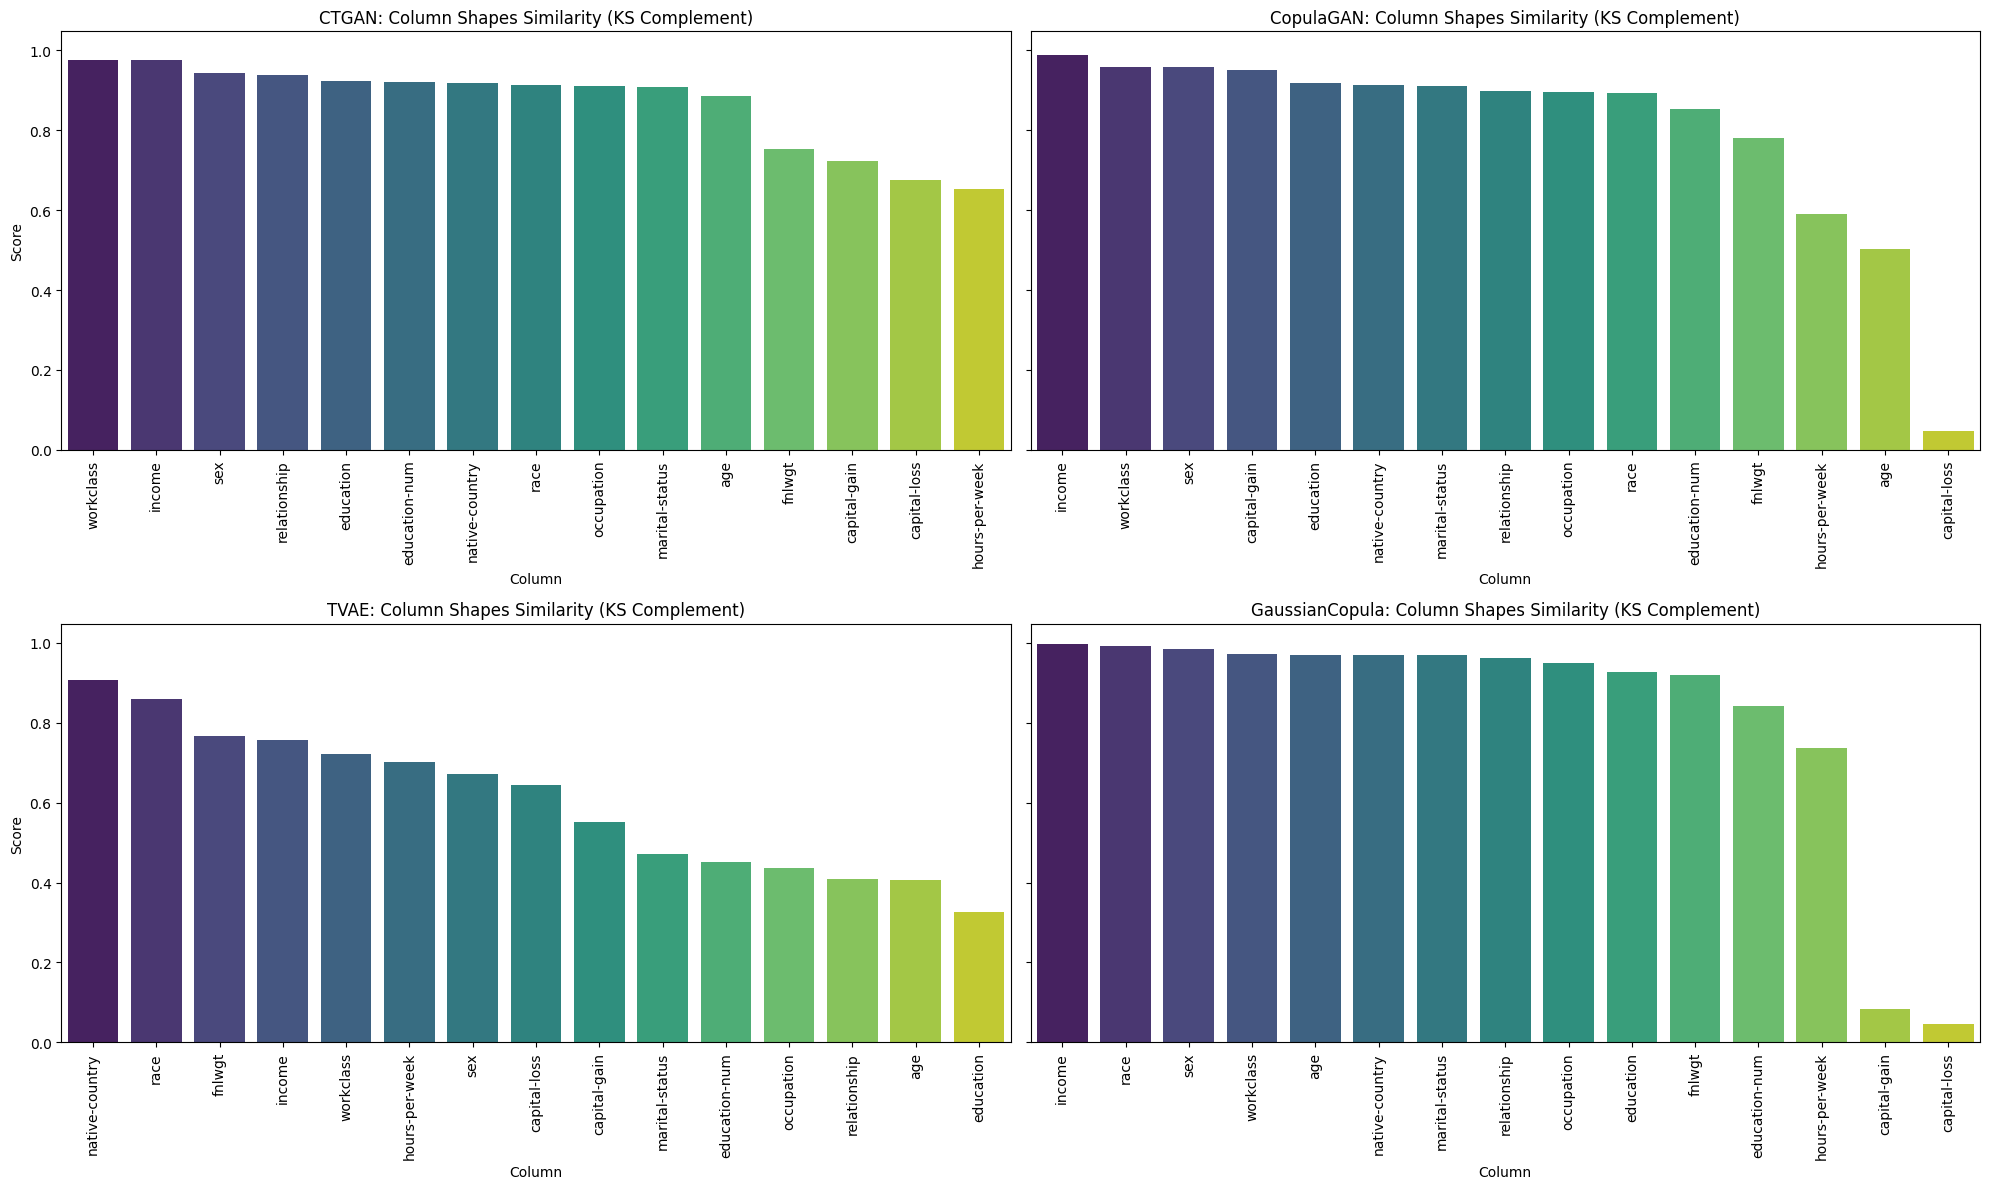

,Column,Metric,Score,Model
0,workclass,TVComplement,0.976555,CTGAN
1,income,TVComplement,0.974472,CTGAN
2,sex,TVComplement,0.942348,CTGAN
3,relationship,TVComplement,0.938560,CTGAN
4,education,TVComplement,0.922368,CTGAN
5,education-num,KSComplement,0.920340,CTGAN
6,native-country,TVComplement,0.917655,CTGAN
7,race,TVComplement,0.913335,CTGAN
8,occupation,TVComplement,0.909692,CTGAN
9,marital-status,TVComplement,0.907470,CTGAN


In [3]:
from sdv.evaluation.single_table import QualityReport
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assumes these already exist from your previous cell:
# - adult_data
# - metadata
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
column_shape_details = {}

for model_name in model_order:
    qr = QualityReport()
    qr.generate(
        real_data=adult_data,
        synthetic_data=synthetic_datasets[model_name],
        metadata=metadata.to_dict()
    )
    details = qr.get_details("Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

# Plot all 4 models in one figure (2x2)
fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    sns.barplot(
        x="Column", y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity (KS Complement)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

# Optional: combined table for quick comparison
combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)
display(combined_details.head(20))

### 1.2. Jensen–Shannon divergence

In [4]:
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")

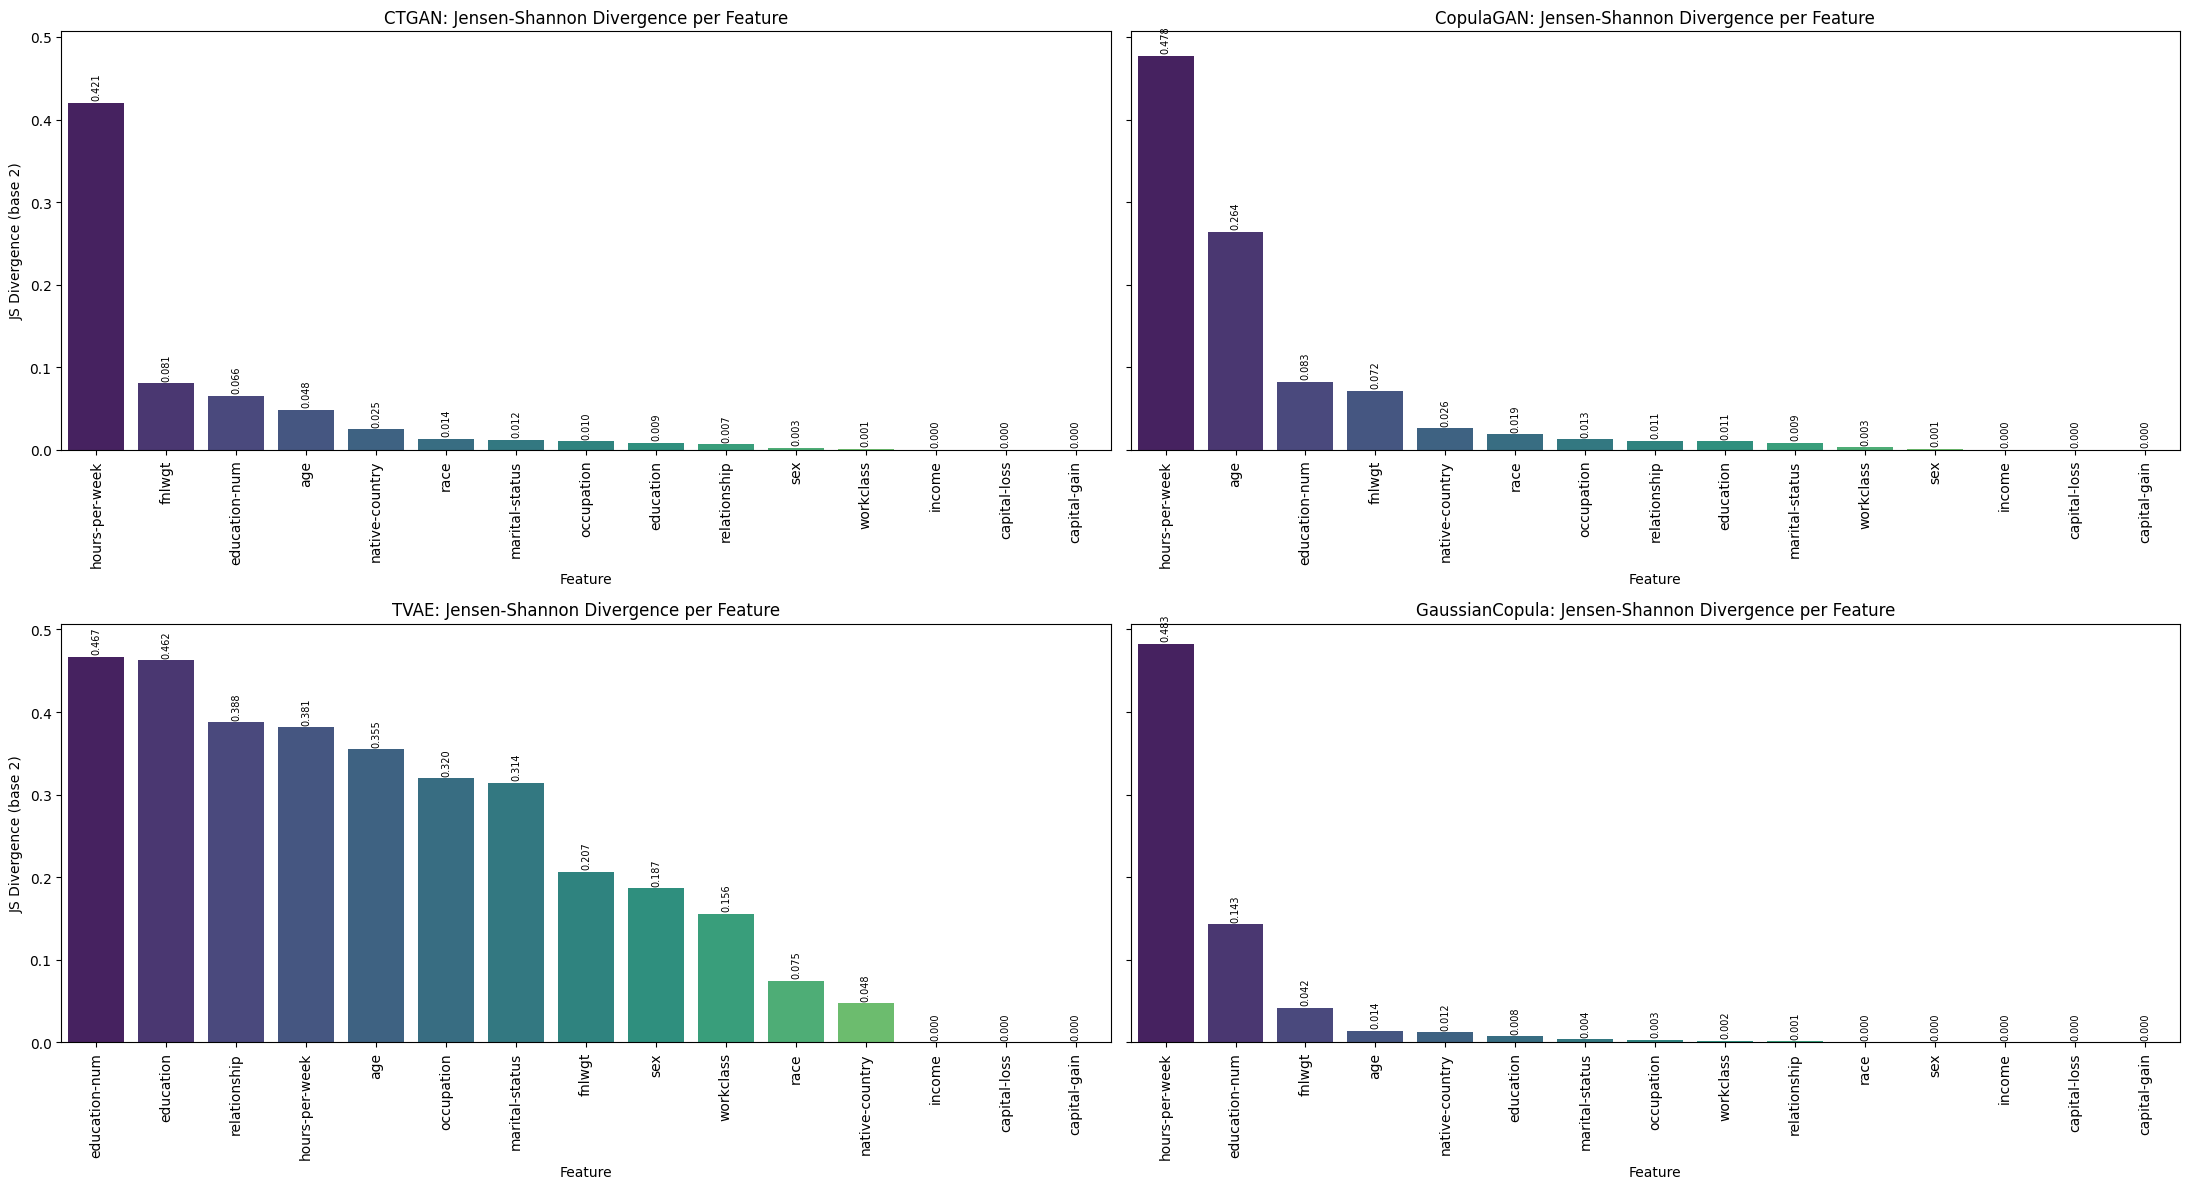

,Feature,JS_Divergence,Model
0,hours-per-week,0.420610,CTGAN
1,fnlwgt,0.080570,CTGAN
2,education-num,0.065636,CTGAN
3,age,0.048332,CTGAN
4,native-country,0.025213,CTGAN
5,race,0.013658,CTGAN
6,marital-status,0.012043,CTGAN
7,occupation,0.010264,CTGAN
8,education,0.008794,CTGAN
9,relationship,0.006902,CTGAN


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
js_results_by_model = {}

# Compute JS divergence for each model
for model_name in model_order:
    js_df = compute_js_divergence(
        adult_data,
        synthetic_datasets[model_name],
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)
    js_results_by_model[model_name] = js_df

# Plot all 4 models in one figure (2x2)
fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]
    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df,
        palette="viridis",
        ax=ax
    )

    # Add value labels
    for bar in bars.patches:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.003,
            f"{yval:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    ax.set_title(f"{model_name}: Jensen-Shannon Divergence per Feature")
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence (base 2)")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

# Optional: combined table for quick comparison
all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)
display(all_js.head(20))

### 1.3 Wasserstein Distance


Wasserstein on 7 numeric columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income']

CTGAN - Wasserstein Distance:
age: 0.0502
fnlwgt: 0.0393
education-num: 0.0342
capital-gain: 0.0091
capital-loss: 0.0147
hours-per-week: 0.0404
income: 0.0255

CopulaGAN - Wasserstein Distance:
age: 0.1882
fnlwgt: 0.0293
education-num: 0.0470
capital-gain: 0.0049
capital-loss: 0.0458
hours-per-week: 0.0623
income: 0.0115

TVAE - Wasserstein Distance:
age: 0.1835
fnlwgt: 0.0327
education-num: 0.1308
capital-gain: 0.0110
capital-loss: 0.0204
hours-per-week: 0.0721
income: 0.2445

GaussianCopula - Wasserstein Distance:
age: 0.0115
fnlwgt: 0.0092
education-num: 0.0419
capital-gain: 0.1658
capital-loss: 0.4111
hours-per-week: 0.0444
income: 0.0025

Model summary (lower is better):


,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,CTGAN,0.030493,0.034209,0.050169
1,CopulaGAN,0.055567,0.045799,0.188157
2,GaussianCopula,0.098072,0.041876,0.411150
3,TVAE,0.099292,0.072140,0.244472


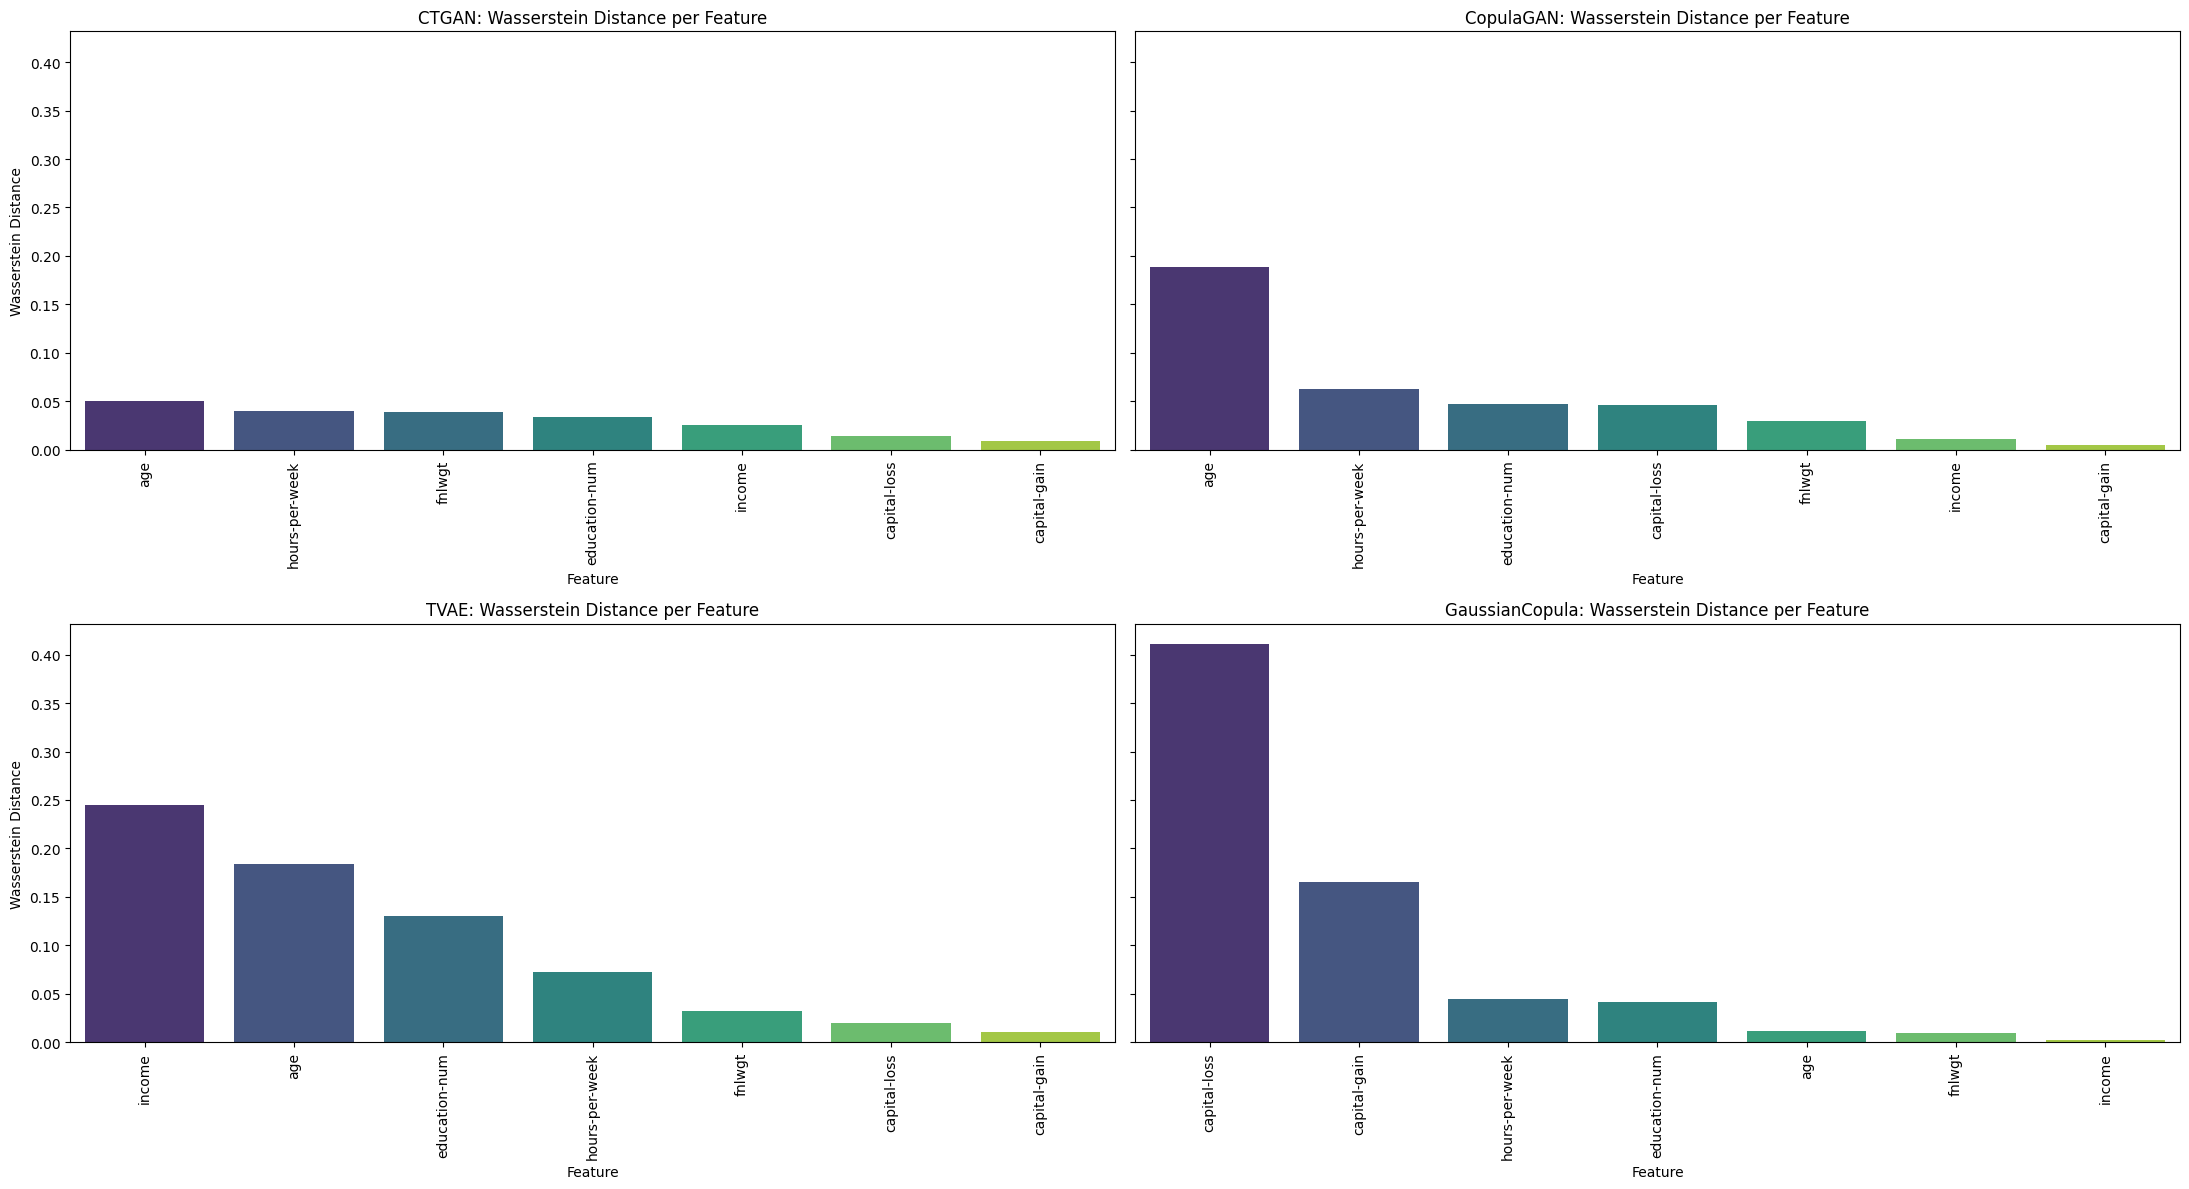

In [6]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes these already exist:
# - adult_data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Adult has categorical columns — scale / compare numeric features only
num_cols = adult_data.select_dtypes(include=[np.number]).columns.tolist()
print(f"Wasserstein on {len(num_cols)} numeric columns: {num_cols}")

# Scale real data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(adult_data[num_cols]),
    columns=num_cols,
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]

    # Ensure same numeric columns / order as real data
    synth_df = synth_df[num_cols]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=num_cols,
    )

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")
    for col in num_cols:
        dist = wasserstein_distance(real_scaled[col], synthetic_scaled[col])
        dists.append((col, dist))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(dists, columns=["Feature", "Wasserstein_Distance"]).sort_values(
        "Wasserstein_Distance", ascending=False
    )
    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": dist_df["Wasserstein_Distance"].mean(),
        "Median_Wasserstein": dist_df["Wasserstein_Distance"].median(),
        "Max_Wasserstein": dist_df["Wasserstein_Distance"].max(),
    })

# Summary table (lower is better)
summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

# Plot all 4 models in one figure
fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Wasserstein Distance per Feature")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()

### 1.4 Gower Distance

In [ ]:
import numpy as np
import pandas as pd
import gower

# Assumes:
# - adult_data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "income"

X_real = adult_data.drop(columns=[target_col], errors="ignore")

gower_results = []

for model_name in model_order:
    X_synth = synthetic_datasets[model_name].drop(columns=[target_col], errors="ignore")

    # Keep same columns/order
    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = X_real[common_cols].reset_index(drop=True)
    Xs = X_synth[common_cols].reset_index(drop=True)

    # Intra-set similarity (1 - Gower distance)
    gower_real = 1 - gower.gower_matrix(Xr)
    gower_synth = 1 - gower.gower_matrix(Xs)

    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = np.max(real_upper)
    avg_intra_real = np.mean(real_upper)
    max_intra_synth = np.max(synth_upper)
    avg_intra_synth = np.mean(synth_upper)

    # Cross-set similarity (real vs synthetic only)
    combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
    gower_combined = 1 - gower.gower_matrix(combined)
    n_real = len(Xr)
    cross_block = gower_combined[:n_real, n_real:]  # real x synthetic

    max_cross = np.max(cross_block)
    avg_cross = np.mean(cross_block)

    print(f"\n{model_name} - Gower Similarity:")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")
    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")
    print("Cross-set Similarity (Real vs Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross_Real_vs_Synth": max_cross,
        "Avg_Cross_Real_vs_Synth": avg_cross,
    })

gower_summary_df = pd.DataFrame(gower_results)
display(gower_summary_df)

### 1.5 t-SNE Visualization


t-SNE on 7 numeric columns


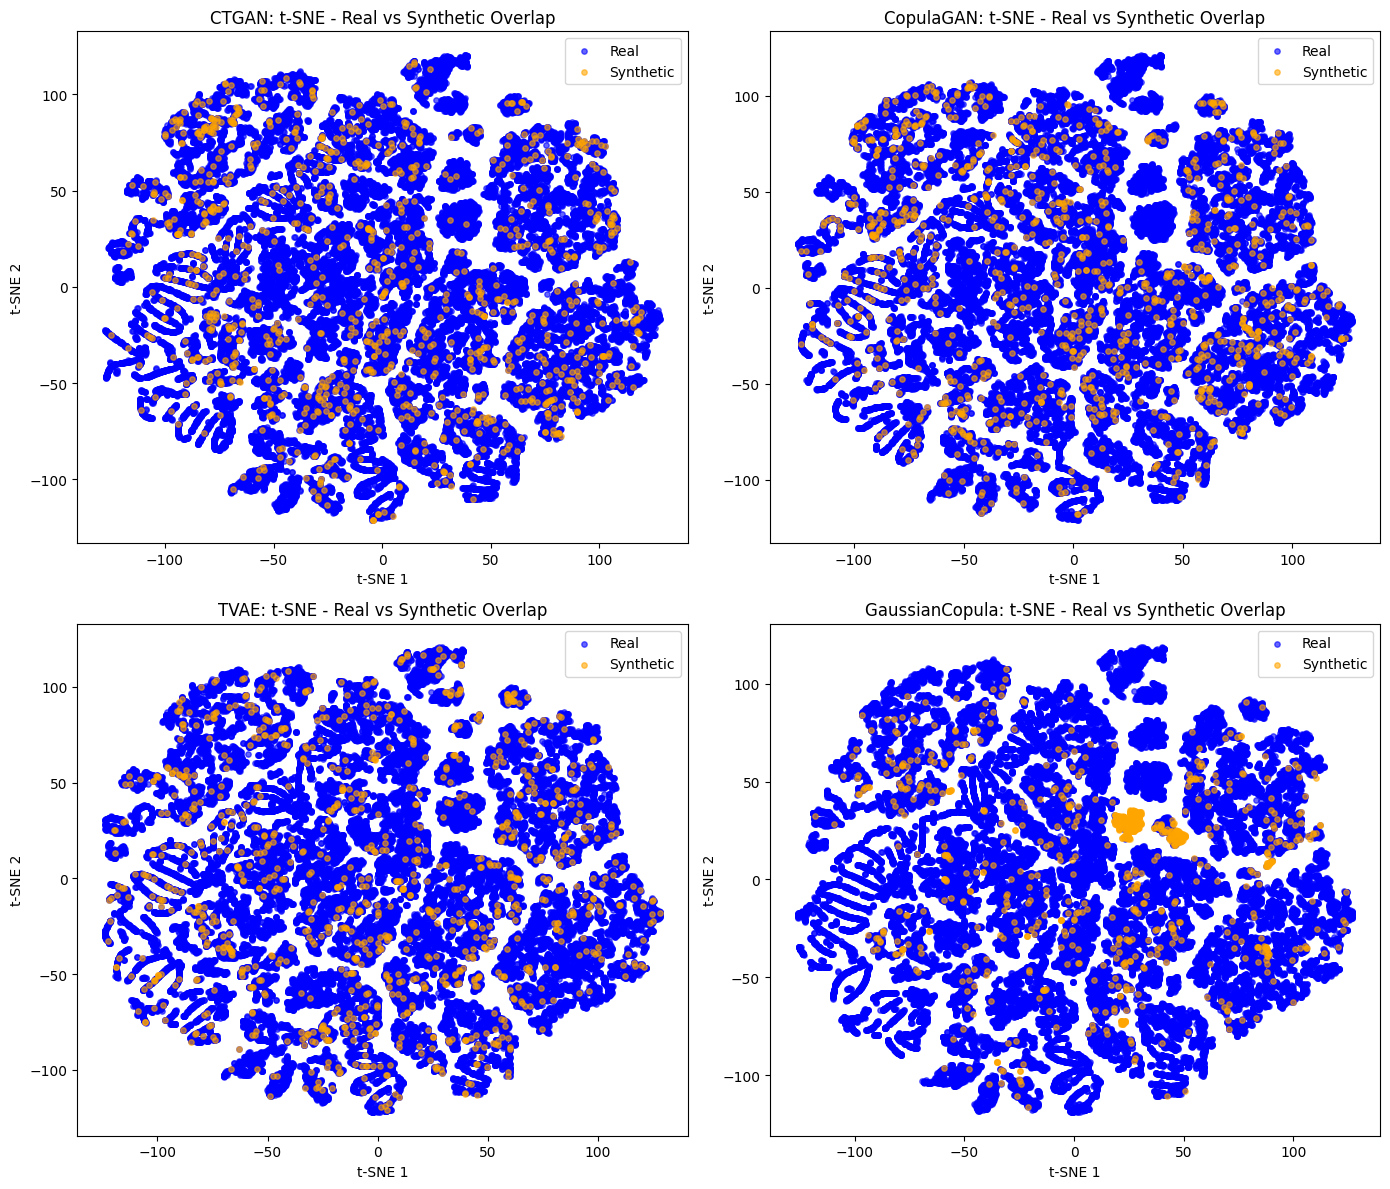

In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes:
# - adult_data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Adult has categorical columns — t-SNE on numeric features only
num_cols = adult_data.select_dtypes(include=[np.number]).columns.tolist()
print(f"t-SNE on {len(num_cols)} numeric columns")

# Scale real data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(adult_data[num_cols]),
    columns=num_cols,
)

# Create 2x2 t-SNE plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_datasets[model_name][num_cols]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=num_cols,
    )

    combined = np.vstack([real_scaled.values, synthetic_scaled.values])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=15, label="Real"
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=15, label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()

### 1.6 MMD (Maximum Mean Discrepancy)


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Assumes:
# - adult_data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

def gaussian_kernel(x, y, sigma=1.0):
    x_size = x.shape[0]
    y_size = y.shape[0]
    dim = x.shape[1]
    x_tile = np.tile(x, (y_size, 1))
    y_tile = np.repeat(y, x_size, axis=0)
    return np.exp(-np.sum((x_tile - y_tile) ** 2, axis=1) / (2 * dim * sigma ** 2)).reshape(y_size, x_size)

def compute_mmd(x, y, sigma=1.0):
    k_xx = np.mean(gaussian_kernel(x, x, sigma))
    k_yy = np.mean(gaussian_kernel(y, y, sigma))
    k_xy = np.mean(gaussian_kernel(x, y, sigma))
    return k_xx + k_yy - 2 * k_xy

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "income"

# Real features (exclude target) — numeric only (Adult has categoricals)
real_features = adult_data.drop(columns=[target_col], errors="ignore")
real_features = real_features.select_dtypes(include=[np.number])

mmd_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]
    synth_features = synth_df.drop(columns=[target_col], errors="ignore")
    synth_features = synth_features.select_dtypes(include=[np.number])

    # Align columns/order
    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols]
    X_synth = synth_features[common_cols]

    # Standardize using real-data stats
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_score = compute_mmd(X_real_scaled, X_synth_scaled, sigma=1.0)
    mmd_results.append({"Model": model_name, "MMD_Score": mmd_score})

    print(f"{model_name} - MMD score: {mmd_score:.4f}")

# Lower MMD is better
mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")
display(mmd_summary_df)

CTGAN - MMD score: 0.0101
CopulaGAN - MMD score: 0.0051
TVAE - MMD score: 0.0212
GaussianCopula - MMD score: 0.1802

MMD comparison (lower is better):


,Model,MMD_Score
0,CopulaGAN,0.005123
1,CTGAN,0.010127
2,TVAE,0.021182
3,GaussianCopula,0.180179


### 1.7 Cosine Similarity


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Assumes:
# - adult_data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "income"
SIM_MAX_ROWS = 2000  # full Adult pairwise cosine is O(n^2) and extremely slow
rng = np.random.default_rng(42)

real_features = adult_data.drop(columns=[target_col], errors="ignore")
real_features = real_features.select_dtypes(include=[np.number])
similarity_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]
    synth_features = synth_df.drop(columns=[target_col], errors="ignore")
    synth_features = synth_features.select_dtypes(include=[np.number])

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].to_numpy(dtype=np.float64)
    X_synth = synth_features[common_cols].to_numpy(dtype=np.float64)

    if X_real.shape[0] > SIM_MAX_ROWS:
        X_real = X_real[rng.choice(X_real.shape[0], size=SIM_MAX_ROWS, replace=False)]
    if X_synth.shape[0] > SIM_MAX_ROWS:
        X_synth = X_synth[rng.choice(X_synth.shape[0], size=SIM_MAX_ROWS, replace=False)]

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = np.mean(cross_sim)
    max_sim = np.max(cross_sim)

    print(f"\n{model_name} - Sample-Level Similarity (n_real={X_real.shape[0]}, n_synth={X_synth.shape[0]}):")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim,
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)



CTGAN - Sample-Level Similarity:
Average cosine similarity: 0.0141
Maximum cosine similarity: 1.0000

CopulaGAN - Sample-Level Similarity:
Average cosine similarity: 0.0160
Maximum cosine similarity: 1.0000

TVAE - Sample-Level Similarity:
Average cosine similarity: 0.0286
Maximum cosine similarity: 1.0000

GaussianCopula - Sample-Level Similarity:
Average cosine similarity: -0.0211
Maximum cosine similarity: 1.0000

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,TVAE,0.028617,1.0
1,CopulaGAN,0.015996,1.0
2,CTGAN,0.014150,1.0
3,GaussianCopula,-0.021114,1.0


### 1.8 Nearest Neighbours 


In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "income"
NN_MAX_ROWS = 5000  # cap Adult for speed
rng = np.random.default_rng(42)

real_features = adult_data.drop(columns=[target_col], errors="ignore")
real_features = real_features.select_dtypes(include=[np.number])
privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]
    synth_features = synth_df.drop(columns=[target_col], errors="ignore")
    synth_features = synth_features.select_dtypes(include=[np.number])

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].to_numpy(dtype=np.float64)
    X_synth = synth_features[common_cols].to_numpy(dtype=np.float64)

    if X_real.shape[0] > NN_MAX_ROWS:
        X_real = X_real[rng.choice(X_real.shape[0], size=NN_MAX_ROWS, replace=False)]
    if X_synth.shape[0] > NN_MAX_ROWS:
        X_synth = X_synth[rng.choice(X_synth.shape[0], size=NN_MAX_ROWS, replace=False)]

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)
    avg_nn_dist = np.mean(distances)
    min_nn_dist = np.min(distances)
    p5_nn_dist = np.percentile(distances, 5)

    print(f"\n{model_name} - Privacy Check (real={X_real.shape[0]}, synth={X_synth.shape[0]}):")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist,
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)



CTGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.1448
Minimum NN Distance (Synthetic -> Real): 0.0000
5th Percentile NN Distance: 0.0023

CopulaGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.1521
Minimum NN Distance (Synthetic -> Real): 0.0000
5th Percentile NN Distance: 0.0017

TVAE - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.1302
Minimum NN Distance (Synthetic -> Real): 0.0000
5th Percentile NN Distance: 0.0021

GaussianCopula - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.2532
Minimum NN Distance (Synthetic -> Real): 0.0005
5th Percentile NN Distance: 0.1345

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,GaussianCopula,1.253248,0.000464,0.134497
1,CopulaGAN,0.152083,0.000019,0.001684
2,CTGAN,0.144830,0.000019,0.002290
3,TVAE,0.130169,0.000028,0.002106


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,18.279341,8.273120,14.553663
1,CopulaGAN,25.356947,5.479784,24.207615
2,TVAE,13.458949,6.856820,19.989527
3,GaussianCopula,462.643438,1.615294,72.033517


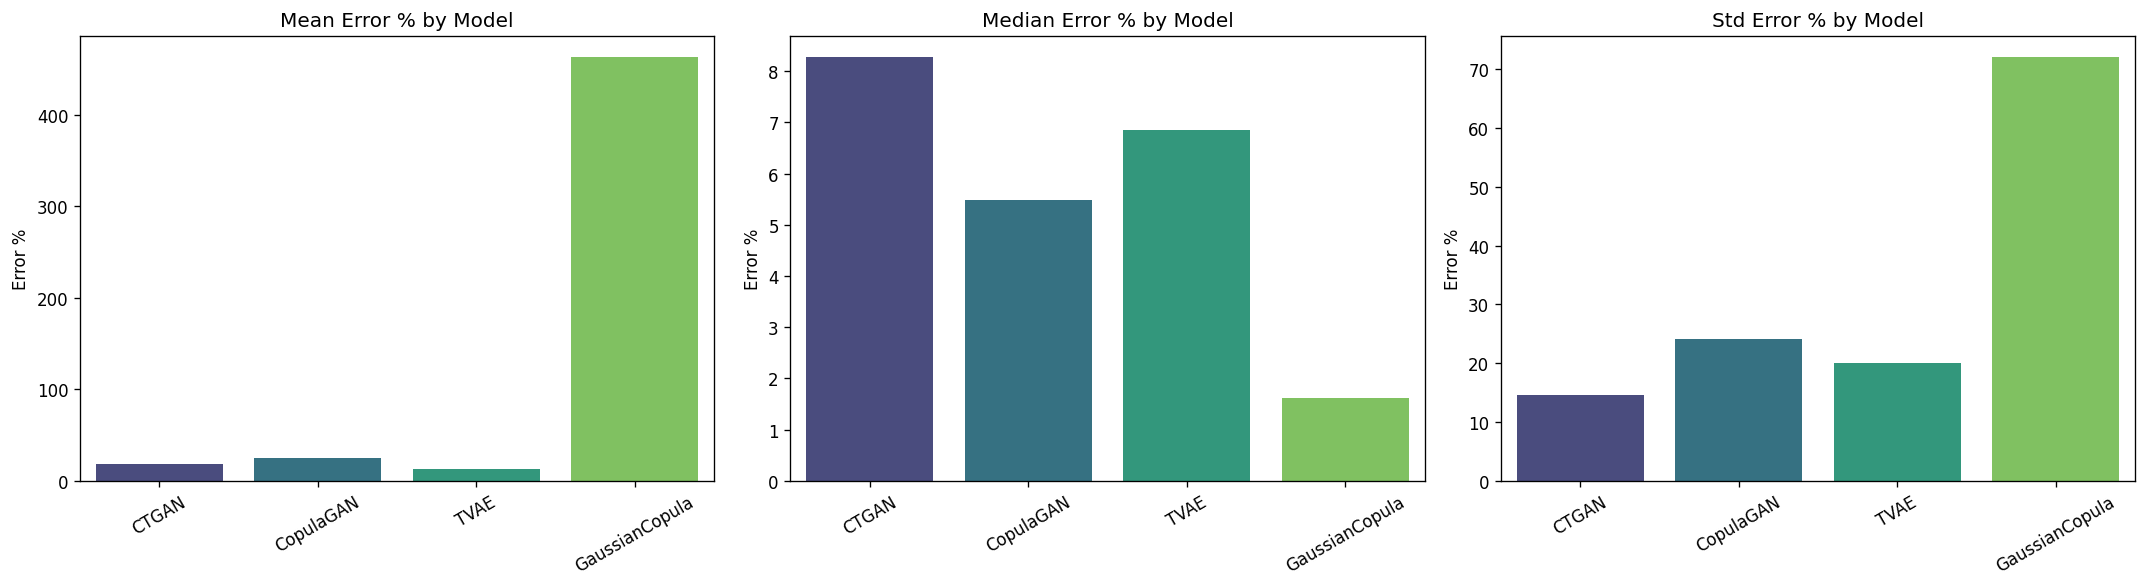

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = adult_data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if "income" in num_cols:
    num_cols.remove("income")

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].mean()
    synth_means = synth_df[num_cols].mean()

    real_stds = real_df[num_cols].std(ddof=1)
    synth_stds = synth_df[num_cols].std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_df = feature_error_df.replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


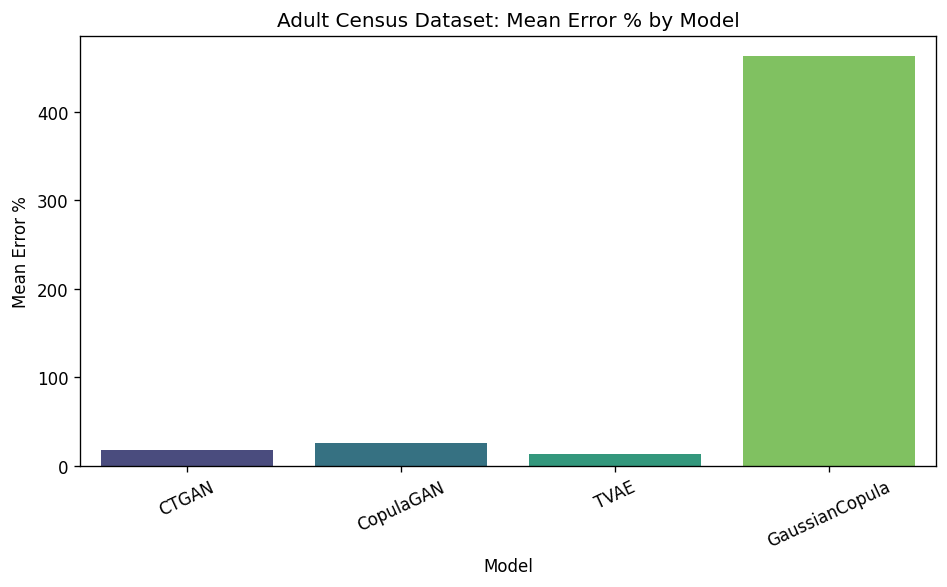

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = summary_df[["Model", "Mean Error %"]].copy()

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")
plt.title("Adult Census Dataset: Mean Error % by Model")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

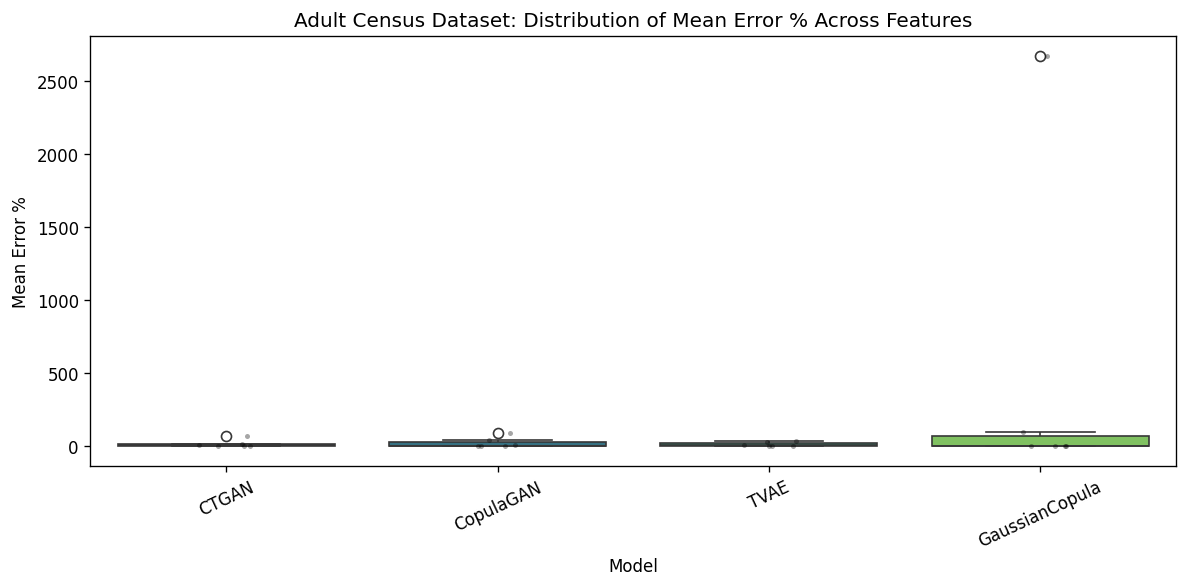

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Adult Census Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

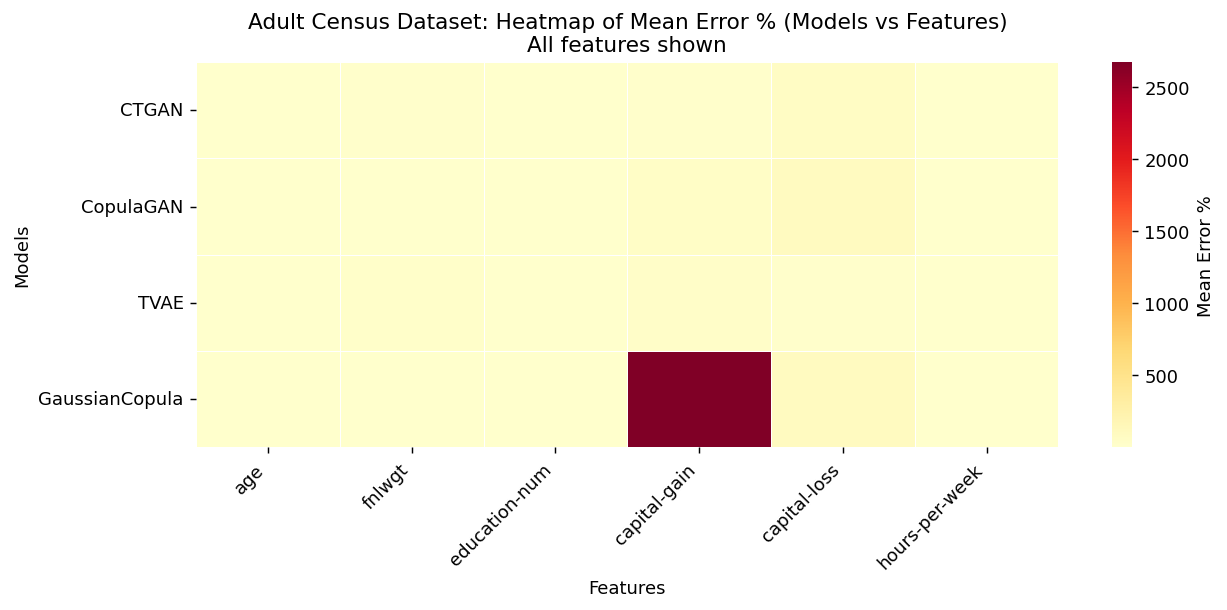

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Adult Census Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2 Bivariate Analysis


In [ ]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

def bivariate_quality_adult(real_df, synth_df, target='income'):
    """Compute bivariate quality metrics for adult census data."""
    num_cols = [c for c in real_df.columns if c != target]
    
    # Min-Max scaling on numeric columns
    scaler = MinMaxScaler()
    
    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()
    
    # Fit on real, transform both real and synthetic
    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])
    
    results_corr = []
    results_target = []

    # Numeric-to-numeric: Δ-correlation
    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            'var_a': a,
            'var_b': b,
            'delta_corr': abs(r_corr - s_corr)
        })
    
    # Numeric-to-target: Δ-Wasserstein between classes
    for col in num_cols:
        r_groups = [g[col].values for _, g in real_scaled.groupby(target)]
        s_groups = [g[col].values for _, g in synth_scaled.groupby(target)]
        
        if len(r_groups) == 2 and len(s_groups) == 2:
            d_real = stats.wasserstein_distance(*r_groups)
            d_synth = stats.wasserstein_distance(*s_groups)
            results_target.append({
                "feature": col,
                "delta_wasserstein": abs(d_real - d_synth)
            })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = pd.DataFrame(results_target).sort_values("delta_wasserstein", ascending=False)
    
    return corr_df, target_df


In [ ]:
# Assumes:
# - adult_data
# - synthetic_datasets dict with keys: "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"
# - bivariate_quality_adult(real_df, synth_df) is already defined

import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = adult_data.copy()

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]  # align column order

    corr_results, target_results = bivariate_quality_adult(
        real_df=real_df,
        synth_df=synth_df
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))
    print("=" * 60)
    print(f"{model_name} - Features that differ most by income class:")
    display(target_results.head(10))
    print("=" * 60)

    # Optional compact summary if score/diff column exists
    corr_metric_col = next((c for c in ["AbsDiff", "abs_diff", "Difference", "diff"] if c in corr_results.columns), None)
    target_metric_col = next((c for c in ["AbsDiff", "abs_diff", "Difference", "diff"] if c in target_results.columns), None)

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results[corr_metric_col].iloc[0] if corr_metric_col else None,
        "MeanTop10CorrDiff": corr_results[corr_metric_col].head(10).mean() if corr_metric_col else None,
        "TopTargetDiff": target_results[target_metric_col].iloc[0] if target_metric_col else None,
        "MeanTop10TargetDiff": target_results[target_metric_col].head(10).mean() if target_metric_col else None,
    })

# Optional model-level summary table (lower differences are better)
summary_df = pd.DataFrame(summary_rows)
display(summary_df)


ValueError: could not convert string to float: 'State-gov'

### 3 Multivariate Analysis


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes:
# - adult_data
# - synthetic_datasets dict with keys: "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = adult_data.copy()
num_cols = [c for c in real_df.columns if c != "income"]

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]  # align columns/order
    synth_corr = synth_df[num_cols].corr()

    # 1) Real vs Synthetic correlation matrices
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(real_corr, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    # 2) Absolute correlation difference heatmap
    diff_corr = (real_corr - synth_corr).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Assumes:
# - adult_data
# - synthetic_datasets dict with keys: "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

def mmd_rbf(X, Y, gamma=None):
    if gamma is None:
        Z = np.vstack([X, Y])
        dists = np.sqrt(((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1))
        med = np.median(dists[dists > 0])
        gamma = 1.0 / (2 * (med ** 2))
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)
    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "income"

X_real_df = adult_data.drop(columns=[target_col], errors="ignore")
X_real_df = X_real_df.select_dtypes(include=[np.number])
results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    X_synth_df = synth_df.drop(columns=[target_col], errors="ignore")
    X_synth_df = X_synth_df.select_dtypes(include=[np.number])

    # Align columns/order
    common_cols = X_real_df.columns.intersection(X_synth_df.columns)
    X_real = X_real_df[common_cols].values
    X_synth = X_synth_df[common_cols].values

    # Standardize using real-data stats
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    # 1) Global MMD (RBF)
    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    # 2) PCA visualization
    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[labels == "Real", 0], X_pca[labels == "Real", 1],
                color="blue", alpha=0.5, label="Real", s=18)
    plt.scatter(X_pca[labels == "Synthetic", 0], X_pca[labels == "Synthetic", 1],
                color="orange", alpha=0.5, label="Synthetic", s=18)
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3) Classifier Two-Sample Test (C2ST)
    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": mmd_value,
        "C2ST_Accuracy": acc
    })

# Summary table
results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)

# 4 Utility with 10 classifiers 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


models = { 

    'LogReg': LogisticRegression(max_iter=5000, solver='liblinear', random_state=42),
    'SVM-RBF': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'ExtraTrees':  ExtraTreesClassifier(random_state=42),
    'GradientBoost': GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
}

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate_models(train_df, test_df, label_col, models, test_size=0.2, seed=42):
    # Split TRAIN df -> (train part only)  (we don’t need train_df's test split)
    X_train = train_df.drop(columns=[label_col])
    y_train = train_df[label_col]

    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed, stratify=y_train
    )

    # Split TEST df -> (test part only)
    X_test = test_df.drop(columns=[label_col])
    y_test = test_df[label_col]

    _, X_test, _, y_test = train_test_split(
        X_test, y_test, test_size=test_size, random_state=seed, stratify=y_test
    )

    # Scale using TRAIN statistics only
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s  = scaler.transform(X_test)

    rows = []
    for name, clf in models.items():
        clf.fit(X_train_s, y_train)

        y_pred = clf.predict(X_test_s)

        # AUC needs probabilities (or decision_function); handle both safely
        if hasattr(clf, "predict_proba"):
            y_prob = clf.predict_proba(X_test_s)[:, 1]
        elif hasattr(clf, "decision_function"):
            scores = clf.decision_function(X_test_s)
            # convert to 0-1-ish range (not perfect prob, but works for AUC)
            y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        else:
            y_prob = None

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred)

        auc = roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan")

        rows.append({"Model": name, "Accuracy": acc, "F1": f1, "AUC": auc})

    return pd.DataFrame(rows).sort_values(by="AUC", ascending=False)

In [ ]:
import pandas as pd

label_col = "income"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=adult_data,
    test_df=adult_data,
    label="income",
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comparisons = []

for synth_name in model_order:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[synth_name],
        test_df=adult_data,
        label="income",
        models=models
    )

    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )

    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]

    if "F1_TRTR" in comparison.columns and "F1_TSTR" in comparison.columns:
        comparison["F1_Drop"] = comparison["F1_TRTR"] - comparison["F1_TSTR"]
    if "Accuracy_TRTR" in comparison.columns and "Accuracy_TSTR" in comparison.columns:
        comparison["Accuracy_Drop"] = comparison["Accuracy_TRTR"] - comparison["Accuracy_TSTR"]

    comparison["Synthetic_Model"] = synth_name
    comparison = comparison.sort_values("AUC_Drop", ascending=False)

    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)

    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)

summary = (combined_comparison
           .groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
           .mean()
           .sort_values("AUC_Drop"))

print("Average AUC drop by synthetic generator (lower is better):")
display(summary)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="AUC"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )
    df["Drop"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    df = df.sort_values("Drop", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w/2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w/2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_auc_drop(comparison_df, synth_name):
    if "AUC_Drop" not in comparison_df.columns:
        return

    df = comparison_df.sort_values("AUC_Drop", ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df["AUC_Drop"])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel("AUC drop (TRTR - TSTR)")
    plt.title(f"{synth_name}: AUC Drop from TRTR to TSTR")
    plt.tight_layout()
    plt.show()

label_col = "income"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=adult_data,
    test_df=adult_data,
    label="income",
    models=models
)

all_comp = []

for synth_name in model_order:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[synth_name],
        test_df=adult_data,
        label="income",
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )
    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR")
    display(tstr_results)

    for metric in ["AUC", "F1", "Accuracy"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric=metric)

    plot_auc_drop(comparison, synth_name)

combined_comparison = pd.concat(all_comp, ignore_index=True)

summary_auc = (combined_comparison.groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
               .mean()
               .sort_values("AUC_Drop"))

print("\nAverage AUC drop by synthetic generator:")
display(summary_auc)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results,
    generator_name,
    ncols=5
):
    metrics = ["Accuracy", "F1", "AUC"]
    x = np.arange(len(metrics))

    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(22, 9),
        dpi=150,
        constrained_layout=True
    )
    axes = np.array(axes).reshape(-1)

    for i, m in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[m].values.astype(float)
        b = tstr.loc[m].values.astype(float)

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="o", label="TSTR")
        ax.fill_between(x, b, a, alpha=0.2)

        ax.set_title(m, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        lo = float(np.nanmin(np.concatenate([a, b])))
        hi = float(np.nanmax(np.concatenate([a, b])))
        pad = max((hi - lo) * 0.15, 0.05) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)

        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="lower left")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{generator_name} - TRTR vs TSTR per classifier (Accuracy, F1, AUC)\n"
        f"Shaded area = generalization gap (TRTR - TSTR)",
        fontsize=14
    )
    plt.show()

label_col = "income"
generators = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=adult_data,
    test_df=adult_data,
    label="income",
    models=models
)

for gen in generators:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[gen],
        test_df=adult_data,
        label="income",
        models=models
    )
    plot_grid_line_metrics_with_gap(
        trtr_results,
        tstr_results,
        generator_name=gen,
        ncols=5
    )


# 5 Statistical similarity tests 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = adult_data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if "income" in num_cols:
    num_cols.remove("income")

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].mean()
    synth_means = synth_df[num_cols].mean()

    real_stds = real_df[num_cols].std(ddof=1)
    synth_stds = synth_df[num_cols].std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_df = feature_error_df.replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = summary_df[["Model", "Mean Error %"]].copy()

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")
plt.title("Adult Census Dataset: Mean Error % by Model")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Adult Census Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Adult Census Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Requires summary_df with columns:
# ["Model", "Mean Error %", "Median Error %", "Std Error %"]

metrics = ["Mean Error %", "Median Error %", "Std Error %"]
radar_df = summary_df[["Model"] + metrics].copy()

# Min-max normalize each metric across models (0 = best / lowest error, 1 = worst / highest error)
norm_df = radar_df.copy()
for m in metrics:
    mn, mx = norm_df[m].min(), norm_df[m].max()
    if mx > mn:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = 0.0

labels = metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, row in norm_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0 (best)", "0.25", "0.50", "0.75", "1 (worst)"])
ax.set_title("Normalized Error Radar (Lower is Better)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))
plt.tight_layout()
plt.show()

display(norm_df)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assumes:
# - adult_data
# - synthetic_datasets = {"CTGAN": df, "CopulaGAN": df, "TVAE": df, "GaussianCopula": df}

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = adult_data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if "income" in num_cols:
    num_cols.remove("income")

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

real_outliers = {c: outlier_count_iqr(real_df[c]) for c in num_cols}

for model in model_order:
    synth_df = synthetic_datasets[model][real_df.columns].copy()
    synth_outliers = {c: outlier_count_iqr(synth_df[c]) for c in num_cols}

    feat_df = pd.DataFrame({
        "Feature": num_cols,
        "Real_Outliers": [real_outliers[c] for c in num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in num_cols]
    })
    feat_df["Abs_Diff_Outlier_Count"] = (feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].mean(),
        "Median_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].median(),
        "Max_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].max()
    })

outlier_summary_df = pd.DataFrame(rows).sort_values("Avg_Abs_Diff_Outlier_Count").reset_index(drop=True)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=outlier_summary_df, x="Model", y="Avg_Abs_Diff_Outlier_Count", palette="viridis")
plt.title("Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Model")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 6. Cosine Similarity with Hungraian Mapping

In [ ]:
from numpy.linalg import norm
import numpy as np
import pandas as pd
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer

# Reuse models fitted in the training cell — do NOT re-train (Adult neural fits are slow).
# Fallback kwargs match the FAST_MODE training cell (GPU + large batch).
gpu_kwargs = globals().get(
    "gpu_kwargs",
    {"enable_gpu": True, "verbose": True, "epochs": 40, "batch_size": 500},
)
_fit_df = globals().get("train_df", adult_data)

if "models" in globals() and isinstance(models, dict) and "CTGAN" in models:
    ctgan = models["CTGAN"]
    copulagan = models["CopulaGAN"]
    tvae = models["TVAE"]
    gaussiancopula = models["GaussianCopula"]
else:
    if "ctgan" not in globals():
        print(f"Fitting CTGAN (not found in session) on {len(_fit_df)} rows...")
        ctgan = CTGANSynthesizer(
            metadata=metadata,
            **{k: v for k, v in gpu_kwargs.items() if k != "enforce_rounding"},
        )
        ctgan.fit(_fit_df)
    if "copulagan" not in globals():
        print(f"Fitting CopulaGAN (not found in session) on {len(_fit_df)} rows...")
        copulagan = CopulaGANSynthesizer(metadata=metadata, **gpu_kwargs)
        copulagan.fit(_fit_df)
    if "tvae" not in globals():
        print(f"Fitting TVAE (not found in session) on {len(_fit_df)} rows...")
        tvae = TVAESynthesizer(metadata=metadata, **gpu_kwargs)
        tvae.fit(_fit_df)
    if "gaussiancopula" not in globals():
        print("Fitting GaussianCopula (not found in session)...")
        gaussiancopula = GaussianCopulaSynthesizer(metadata=metadata)
        gaussiancopula.fit(_fit_df)

synth_models = {
    "CTGAN": ctgan,
    "CopulaGAN": copulagan,
    "TVAE": tvae,
    "GaussianCopula": gaussiancopula,
}

# Cap matrix size — full Adult cosine is ~48k x 48k (~18GB+) and very slow
COSINE_MAX_ROWS = 2000
rng = np.random.default_rng(42)

n_rows = min(COSINE_MAX_ROWS, len(adult_data))
synthetic_data = {}
for name, synth in synth_models.items():
    if "synthetic_datasets" in globals() and name in synthetic_datasets:
        synthetic_data[name] = synthetic_datasets[name]
        # upsample/downsample to n_rows if needed
        if len(synthetic_data[name]) != n_rows:
            synthetic_data[name] = synth.sample(num_rows=n_rows)[adult_data.columns]
    else:
        synthetic_data[name] = synth.sample(num_rows=n_rows)[adult_data.columns]

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

cosine_results = {}
cosine_dfs = {}

num_cols = adult_data.select_dtypes(include=[np.number]).columns
real_idx = rng.choice(len(adult_data), size=n_rows, replace=False) if len(adult_data) > n_rows else np.arange(len(adult_data))
real_matrix = normalize_rows(adult_data.iloc[real_idx][num_cols].to_numpy())

for model_name, synth_df in synthetic_data.items():
    print(f"Building cosine similarity DataFrame for {model_name} (n={n_rows})...")

    synth_matrix = normalize_rows(synth_df[num_cols].to_numpy()[:n_rows])
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)],
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max()),
    }

    print(cosine_df, "\n")

display(pd.DataFrame(cosine_results).T)


In [ ]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

def normalize_rows(X):
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()

    R = real_data[num_cols].to_numpy(dtype=float)
    S = synthetic_data[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = adult_data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df[data.columns]
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")

In [ ]:
# Hungarian Mapping (subsampled — full Adult Hungarian is intractable)

import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

HUNGARIAN_MAX_ROWS = 1000  # O(n^3) — keep small
rng = np.random.default_rng(42)

real_full = adult_data.copy()
if len(real_full) > HUNGARIAN_MAX_ROWS:
    real_df = real_full.sample(n=HUNGARIAN_MAX_ROWS, random_state=42).reset_index(drop=True)
else:
    real_df = real_full.reset_index(drop=True)

# Prefer already-fitted synthesizers / synthetic_datasets from the training cell
if "models" in globals() and isinstance(models, dict) and "CTGAN" in models:
    synth_models = models
elif "synth_models" in globals():
    synth_models = synth_models
else:
    raise RuntimeError(
        "No fitted models found. Run the training cell first "
        "(do not re-fit here — that duplicates hours of GPU work)."
    )

synthetic_tables = {}
for name, synth in synth_models.items():
    if "synthetic_datasets" in globals() and name in synthetic_datasets:
        src = synthetic_datasets[name]
        if len(src) >= len(real_df):
            synthetic_tables[name] = src.sample(n=len(real_df), random_state=42).reset_index(drop=True)[real_df.columns]
        else:
            synthetic_tables[name] = synth.sample(num_rows=len(real_df))[real_df.columns]
    else:
        synthetic_tables[name] = synth.sample(num_rows=len(real_df))[real_df.columns]

results = {}

for name, synth_df in synthetic_tables.items():
    print(f"\n==============================")
    print(f"{name}: Hungarian matching on {len(real_df)} rows (cosine, numeric features)")
    print(f"==============================")

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")


In [ ]:
%pip install xlsxwriter 

In [ ]:
import pandas as pd
import numpy as np

real_df = adult_data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

if "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found. Expected `synthetic_data` or `synthetic_tables`.")

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
output_file = "Matchings_All_Models_Adult_Census.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results:
            continue
        if model_name not in synth_source:
            continue

        row_ind = results[model_name]["row_ind"]
        col_ind = results[model_name]["col_ind"]
        sims = results[model_name]["similarities"]

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            "cosine_similarity": sims
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name][real_df.columns]
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        sheet_name = model_name[:31]
        side_by_side.to_excel(writer, sheet_name=sheet_name, index=False)

        combined_rows.append(side_by_side)
        summary_rows.append({
            "Model": model_name,
            "Num_Matches": len(sims),
            "Avg_Cosine_Similarity": float(np.mean(sims)),
            "Median_Cosine_Similarity": float(np.median(sims)),
            "Min_Cosine_Similarity": float(np.min(sims)),
            "Max_Cosine_Similarity": float(np.max(sims)),
        })

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows).sort_values("Avg_Cosine_Similarity", ascending=False)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)

print(f"Saved: {output_file}")
display(summary_df)

# 7. Mahalanobis distance with Hungrain Mapping  

In [ ]:
import numpy as np
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

data_numeric = adult_data.select_dtypes(include=[np.number]).dropna().copy()
real_matrix = data_numeric.to_numpy(dtype=float)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real data.")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")

In [ ]:
mahalanobis_results = {}
num_cols = adult_data.select_dtypes(include=[np.number]).columns.tolist()

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][num_cols].copy()
    synth_numeric = synth_df.to_numpy(dtype=float)

    dists = mahalanobis_distances_to_distribution(synth_numeric, mu_real, inv_cov_real)

    mahalanobis_results[name] = {
        "mean": float(np.mean(dists)),
        "median": float(np.median(dists)),
        "std": float(np.std(dists)),
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
        "distances": dists,
    }

summary = pd.DataFrame({
    name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
    for name, r in mahalanobis_results.items()
}, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T

summary.index.name = "Model"
summary = summary.sort_values("mean_dist")

print("Mahalanobis distance to real distribution (lower is better):")
display(summary)

In [ ]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle("Mahalanobis distance of synthetic samples to real distribution", fontsize=12)
plt.tight_layout()

ROOT = os.getcwd()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
plt.savefig(
    os.path.join(ROOT, "figures", "mahalanobis_cancer_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

hungarian_results = {}

num_cols = adult_data.select_dtypes(include=[np.number]).columns.tolist()
real_matrix = adult_data[num_cols].to_numpy(dtype=float)
n_samples = len(real_matrix)

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name][num_cols].to_numpy(dtype=float)
    assert synth_numeric.shape[0] == n_samples, (
        f"Synthetic size {synth_numeric.shape[0]} != real size {n_samples}"
    )

    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    row_ind, col_ind = linear_sum_assignment(D)
    matched_distances = D[row_ind, col_ind]

    hungarian_results[name] = {
        "total_distance": float(matched_distances.sum()),
        "mean_distance_per_match": float(matched_distances.mean()),
        "median_distance_per_match": float(np.median(matched_distances)),
        "std_distance_per_match": float(np.std(matched_distances)),
        "max_distance_per_match": float(matched_distances.max()),
        "matched_distances": matched_distances,
        "row_ind": row_ind,
        "col_ind": col_ind,
    }

hungarian_summary = pd.DataFrame(
    {
        name: [
            r["mean_distance_per_match"],
            r["median_distance_per_match"],
            r["std_distance_per_match"],
            r["max_distance_per_match"],
        ]
        for name, r in hungarian_results.items()
    },
    index=[
        "mean_distance_per_match",
        "median_distance_per_match",
        "std_distance_per_match",
        "max_distance_per_match",
    ],
).T

hungarian_summary.index.name = "Model"
hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

print("Hungarian matching using Mahalanobis distance (lower is better):")
display(hungarian_summary)

In [ ]:
# Greedy mapping 

import numpy as np
import pandas as pd

def greedy_one_to_one_matching(D):
    n_rows, n_cols = D.shape
    n = min(n_rows, n_cols)

    used_rows = set()
    used_cols = set()
    pairs = []

    for _ in range(n):
        best_val = np.inf
        best_i, best_j = -1, -1

        for i in range(n_rows):
            if i in used_rows:
                continue
            for j in range(n_cols):
                if j in used_cols:
                    continue
                if D[i, j] < best_val:
                    best_val = D[i, j]
                    best_i, best_j = i, j

        if best_i < 0:
            break

        used_rows.add(best_i)
        used_cols.add(best_j)
        pairs.append((best_i, best_j, best_val))

    distances = np.array([p[2] for p in pairs], dtype=float)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

greedy_results = {}
comparison_rows = []

num_cols = adult_data.select_dtypes(include=[np.number]).columns.tolist()
real_matrix = adult_data[num_cols].to_numpy(dtype=float)

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name][num_cols].to_numpy(dtype=float)

    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    total_g, mean_g, _ = greedy_one_to_one_matching(D)

    greedy_results[name] = {
        "total_distance": total_g,
        "mean_distance": mean_g
    }

    h_total = hungarian_results[name]["total_distance"]
    h_mean = hungarian_results[name]["mean_distance_per_match"]

    comparison_rows.append({
        "Model": name,
        "Greedy total": total_g,
        "Hungarian total": h_total,
        "Greedy mean": mean_g,
        "Hungarian mean": h_mean,
        "Total diff (Greedy - Hungarian)": total_g - h_total,
        "Mean diff (Greedy - Hungarian)": mean_g - h_mean,
    })

greedy_summary = pd.DataFrame({
    name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
    for name in greedy_results
}, index=["total_distance", "mean_distance"]).T
greedy_summary.index.name = "Model"

print("Greedy one-to-one matching (Mahalanobis distance):")
display(greedy_summary)

print("\nComparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):")
comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_df)

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=float)
    S = synth_df[feature_cols].to_numpy(dtype=float)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=float), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = adult_data.copy()

feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != "income"]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=float)
mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")

In [ ]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

feature_cols = [c for c in adult_data.select_dtypes(include=[np.number]).columns if c != "income"]
real_df = adult_data.copy()
X_real = real_df[feature_cols].to_numpy(dtype=float)

cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
hungarian_results = {}

for model_name in model_order:
    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_synth = synth_df[feature_cols].to_numpy(dtype=float)

    D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    if D.shape[0] <= D.shape[1]:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    hungarian_results[model_name] = {"row_ind": row_ind, "col_ind": col_ind, "dists": dists}

    order = np.argsort(dists)
    top_k = min(20, len(order))

    print(f"\n{model_name} - Top {top_k} Hungarian matchings (lowest Mahalanobis distance):")
    for rank, k in enumerate(order[:top_k], 1):
        print(f"{rank:02d}. R{row_ind[k] + 1} -> S{col_ind[k] + 1}   distance = {dists[k]:.4f}")

In [ ]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

feature_cols = [c for c in adult_data.select_dtypes(include=[np.number]).columns if c != "income"]
real_df = adult_data.copy()
X_real = real_df[feature_cols].to_numpy(dtype=float)

cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

for model_name in model_order:
    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_synth = synth_df[feature_cols].to_numpy(dtype=float)

    D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    if D.shape[0] <= D.shape[1]:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

    print(f"\n{model_name} - Hungarian mappings for R1 to R20:")
    for r in range(20):
        if r in r_to_match:
            s, dist = r_to_match[r]
            print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
        else:
            print(f"R{r+1} -> No match found")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = adult_data.copy()
feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != "income"]

X_r = real_df[feature_cols].to_numpy(dtype=float)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synthetic_data:
        print(f"{model_name} not found in synthetic_data, skipping.")
        continue

    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_s = synth_df[feature_cols].to_numpy(dtype=float)
    X_s_s = scaler.transform(X_s)

    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = inv(cov_z + 10 * reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
display(summary_df)

In [ ]:
# print results on excel sheets 

import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Hungarian_Mahalanobis_Four_Models_Adult_Census.xlsx"
):
    model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                continue

            synth_df = synthetic_data[model_name].copy()
            _common = [c for c in real_df.columns if c in synth_df.columns]

            synth_df = synth_df[_common]

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["distances"]
            elif "selected_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["selected_distances"]
            else:
                raise KeyError(f"No distance array found for {model_name}")

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                for c in num_cols:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            matched_df.to_excel(writer, sheet_name=model_name[:31], index=False)

            summary_rows.append({
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name="Summary", index=False)

    print(f"Excel file created: {filename}")

# ---- Run ----
real_df = adult_data.copy()
num_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != "income"]

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synthetic_data,
    hungarian_results=hungarian_results,
    num_cols=num_cols,
    filename="Hungarian_Mahalanobis_Four_Models_Adult_Census.xlsx"
)


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [ ]:
# MIA with ML regression model 

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample(model, X, y, eps=1e-15):
    proba = model.predict_proba(X)
    n = len(y)
    y_idx = y.astype(int).clip(0, proba.shape[1] - 1)
    p_true = proba[np.arange(n), y_idx] + eps
    return -np.log(p_true)

def privacy_metrics_mia(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    model.fit(X_train_s, y_train)

    loss_train = model_loss_per_sample(model, X_train_s, y_train)
    loss_test = model_loss_per_sample(model, X_test_s, y_test)

    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")

    return {"AUC": auc, "Advantage": advantage, "TPR_at_FPR_001": tpr_at_fpr_001}

target_col = "income"
feature_cols = [c for c in adult_data.select_dtypes(include=[np.number]).columns if c != target_col]

real_df = adult_data.copy()
synth_df = synthetic_data["GaussianCopula"][real_df.columns].copy()

X_train = real_df[feature_cols].to_numpy(dtype=float)
y_train = real_df[target_col].to_numpy(dtype=int)

X_test = synth_df[feature_cols].to_numpy(dtype=float)
y_test = synth_df[target_col].to_numpy(dtype=int)

model = LogisticRegression(max_iter=1000, random_state=42)
metrics = privacy_metrics_mia(model, X_train, y_train, X_test, y_test)
print(metrics)

In [ ]:
# MIA with Mahalanobis 

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

feature_cols = [c for c in adult_data.select_dtypes(include=[np.number]).columns if c != "income"]
X_train = adult_data[feature_cols].to_numpy(dtype=float)

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
rows = []

for model_name in model_order:
    X_test = synthetic_data[model_name][feature_cols].to_numpy(dtype=float)
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

comparison_df = pd.DataFrame(rows)[
    ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
].sort_values("AUC", ascending=False).reset_index(drop=True)

print("MIA (Mahalanobis) comparison across 4 synthetic models:")
display(comparison_df)